# Dollar Neutral: V Long / MA Short (Dynamic Hedge Ratio)

This notebook demonstrates a **dynamic hedge ratio** approach for the Dollar Neutral strategy
using Visa (V) as the long leg and Mastercard (MA) as the short leg.

Instead of a fixed 1:1 ratio, we calculate the hedge ratio based on **60-day rolling volatility**:
- **Target Ratio = Volatility(Long) / Volatility(Short)**
- This ensures equal risk contribution from both positions
- Aims to improve Sharpe Ratio while maintaining market neutrality

BIL (SPDR Bloomberg 1-3 Month T-Bill ETF) absorbs collateral and residual cash.

**Data**: Yahoo Finance (auto-adjusted)  
**Rebalance**: Monthly mid-month (`month_mid` = 15th of each month)  
**Volatility Window**: 60 trading days (~3 months)  

**Rationale**: Fixed 50/50 allocation achieved beta reduction but low Sharpe Ratio.
Dynamic volatility-based sizing should equalize risk contributions and improve risk-adjusted returns.

# Notebook Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Import tiportfolio modules
from tiportfolio.helpers.cache import enable_data_source_cache
from tiportfolio.helpers.data import YFinance
from tiportfolio import (
    DollarNeutral, FixRatio, Schedule, ScheduleBasedEngine,
    compare_strategies, plot_strategy_comparison_interactive,
    rebalance_decisions_table,
)

# Enable caching for data fetching
enable_data_source_cache("tiportfolio", cache_dir=".cache")

# Define assets and parameters
LONG   = "V"
SHORT  = "MA"
CASH   = "BIL"
VOLATILITY_WINDOW = 60  # 60 trading days for rolling volatility
START  = "2023-01-01"   # Extended start for better analysis
END    = "2024-12-31"
INITIAL_VALUE = 10_000

symbols = [LONG, SHORT, CASH]

print(f"Dynamic Hedge Ratio Setup:")
print(f"Long Asset: {LONG}")
print(f"Short Asset: {SHORT}")
print(f"Cash Asset: {CASH}")
print(f"Volatility Window: {VOLATILITY_WINDOW} days")

Dynamic Hedge Ratio Setup:
Long Asset: V
Short Asset: MA
Cash Asset: BIL
Volatility Window: 60 days


## Data Loading and Preparation

Load historical price data for V, MA, and BIL to prepare for backtesting.

In [2]:
# Set up data fetcher
yf = YFinance(auto_adjust=True)

print(f"Loading data for {symbols} from {START} to {END}...")

# Fetch price data
df = yf.query(symbols, START, END)

prices = {}
for symbol in df["symbol"].unique():
    sub = df[df["symbol"] == symbol].set_index("date")[["open", "high", "low", "close"]]
    prices[symbol] = sub

# Display data summary
for symbol, df in prices.items():
    print(f"{symbol}: {len(df)} trading days from {df.index[0].date()} to {df.index[-1].date()}")
    
# # Show sample data
# print("\nSample price data:")
# for symbol in symbols:
#     print(prices[symbol].tail())

Loading data for ['V', 'MA', 'BIL'] from 2023-01-01 to 2024-12-31...
Loaded cached bar data.

BIL: 501 trading days from 2023-01-03 to 2024-12-30
MA: 501 trading days from 2023-01-03 to 2024-12-30
V: 501 trading days from 2023-01-03 to 2024-12-30


# Baseline Fixed Ratio Backtest

Create a baseline backtest using the fixed 50/50 ratio for comparison.

In [3]:
# Symmetric book sizes (50/50)
RATIO_BS = 1.0
LONG_BS  = 1.0 / (1.0 + RATIO_BS)   # = 0.5
SHORT_BS = RATIO_BS / (1.0 + RATIO_BS)  # = 0.5
print(f"long_book_size={LONG_BS:.4f}  short_book_size={SHORT_BS:.4f}  ratio={SHORT_BS/LONG_BS:.4f}")

# Create baseline fixed ratio strategy for comparison
baseline_strategy = DollarNeutral(
    long_weights={LONG: 1.0},
    short_weights={SHORT: 1.0},
    cash_symbol=CASH,
    long_book_size=LONG_BS,
    short_book_size=SHORT_BS,
    tolerance=0.05,
)

# Set up baseline backtest
baseline_engine = ScheduleBasedEngine(
    allocation=baseline_strategy,
    rebalance=Schedule("month_mid"),
    fee_per_share=0.0035,
    initial_value=INITIAL_VALUE,
)

baseline_result = baseline_engine.run(
    symbols=symbols,
    start=START, 
    end=END,
    prices_df=prices
)

# Display baseline results
print(baseline_result.summary())

long_book_size=0.5000  short_book_size=0.5000  ratio=1.0000
Backtest Summary
----------------
Sharpe Ratio:        0.1230
Sortino Ratio:       0.1700
MAR Ratio:           0.8118
CAGR:                4.66%
Max Drawdown:        5.73%
Kelly Leverage:      2.0112
Mean Excess Return:  0.0075
Final Value:         10,947.99
Total Fee:           0.06
Rebalances:          24


# Dynamic Ratio Implementation

##  Rolling Volatility Calculation

Implement the volatility calculation function using 60-day rolling standard deviation.

Rolling Volatility Calculation (Window: 60 days)
Long Asset (V) - Latest Volatility: 0.1790
Short Asset (MA) - Latest Volatility: 0.1568
Volatility Ratio (Long/Short): 1.1414

Volatility Statistics:
V - Mean: 0.1584, Std: 0.0281, Min: 0.1032, Max: 0.2192
MA - Mean: 0.1613, Std: 0.0218, Min: 0.1116, Max: 0.1993


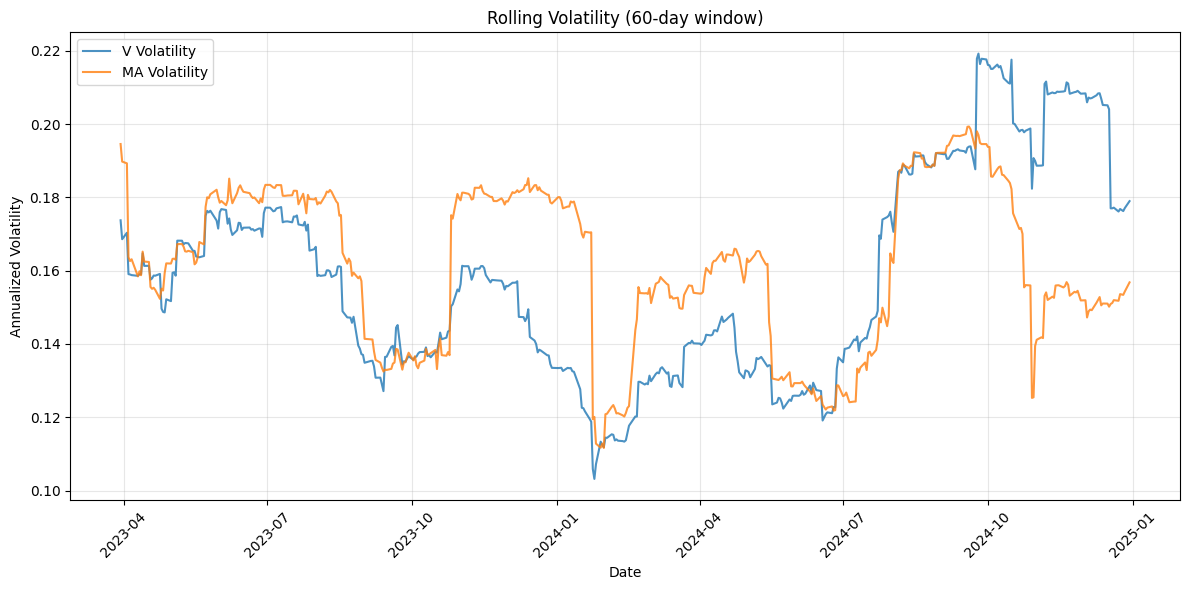

In [4]:
def calculate_rolling_volatility(prices_dict, long_symbol, short_symbol, window=VOLATILITY_WINDOW):
    """
    Calculate rolling volatility for long and short assets.
    
    Args:
        prices_dict: Dictionary of price DataFrames
        long_symbol: Symbol for long asset (V)
        short_symbol: Symbol for short asset (MA)
        window: Rolling window size in days
    
    Returns:
        tuple: (long_volatility, short_volatility) as pandas Series
    """
    # Extract close prices for both assets
    long_prices = prices_dict[long_symbol]['close']
    short_prices = prices_dict[short_symbol]['close']
    
    # Calculate daily returns
    long_returns = long_prices.pct_change()
    short_returns = short_prices.pct_change()
    
    # Calculate rolling volatility (annualized)
    long_volatility = long_returns.rolling(window=window).std() * np.sqrt(252)
    short_volatility = short_returns.rolling(window=window).std() * np.sqrt(252)
    
    return long_volatility, short_volatility

# Test the volatility calculation
long_vol, short_vol = calculate_rolling_volatility(prices, LONG, SHORT, VOLATILITY_WINDOW)

print(f"Rolling Volatility Calculation (Window: {VOLATILITY_WINDOW} days)")
print(f"Long Asset ({LONG}) - Latest Volatility: {long_vol.iloc[-1]:.4f}")
print(f"Short Asset ({SHORT}) - Latest Volatility: {short_vol.iloc[-1]:.4f}")
print(f"Volatility Ratio (Long/Short): {long_vol.iloc[-1]/short_vol.iloc[-1]:.4f}")

# Show volatility statistics
print("\nVolatility Statistics:")
print(f"{LONG} - Mean: {long_vol.mean():.4f}, Std: {long_vol.std():.4f}, Min: {long_vol.min():.4f}, Max: {long_vol.max():.4f}")
print(f"{SHORT} - Mean: {short_vol.mean():.4f}, Std: {short_vol.std():.4f}, Min: {short_vol.min():.4f}, Max: {short_vol.max():.4f}")

# Plot volatility series
plt.figure(figsize=(12, 6))
plt.plot(long_vol.index, long_vol, label=f'{LONG} Volatility', alpha=0.8)
plt.plot(short_vol.index, short_vol, label=f'{SHORT} Volatility', alpha=0.8)
plt.title(f'Rolling Volatility ({VOLATILITY_WINDOW}-day window)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Dynamic Hedge Ratio Formula
Calculate the target ratio based on relative volatilities and convert to portfolio weights with bounds to prevent extreme allocations.

Dynamic Hedge Ratio Analysis
Current Raw Ratio (V/MA): 1.1414
Current Clamped Ratio: 1.1414
Ratio Range: 0.6968 to 1.5202

Corresponding Weights:
  Long (V): 0.4670 (46.7%)
  Short (MA): 0.5330 (53.3%)


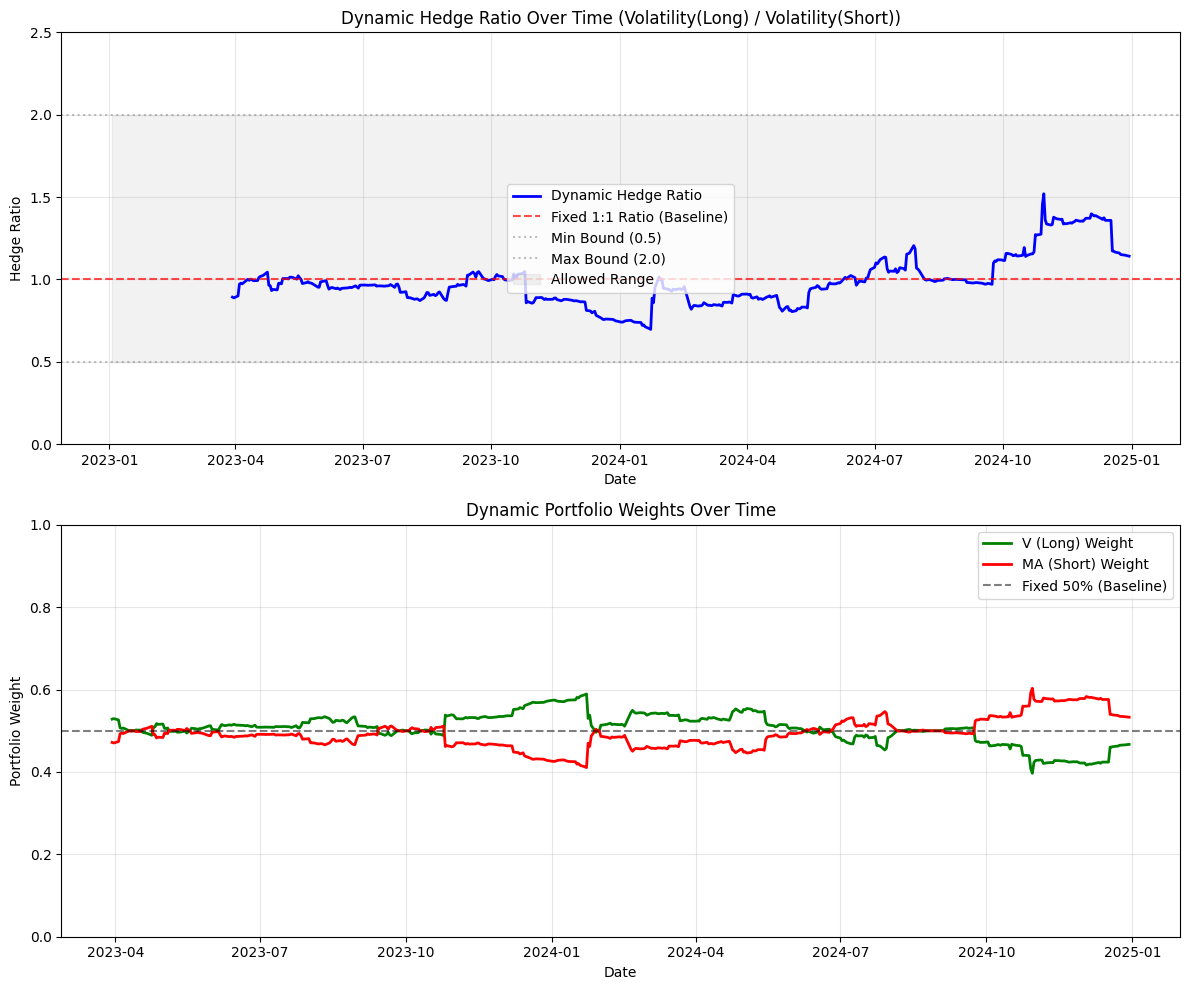

Dynamic Ratio Statistics:
  Mean: 0.9868
  Median: 0.9692
  Std: 0.1505
  Min: 0.6968
  Max: 1.5202

Weight Range:
  V: 39.7% to 58.9%
  MA: 41.1% to 60.3%


In [5]:
def calculate_dynamic_hedge_ratio(long_vol, short_vol, min_ratio=0.5, max_ratio=2.0):
    """
    Calculate dynamic hedge ratio based on relative volatilities.
    
    Formula: Target Ratio = Volatility(Long) / Volatility(Short)
    
    Args:
        long_vol: Rolling volatility series for long asset
        short_vol: Rolling volatility series for short asset
        min_ratio: Minimum allowed ratio to prevent extreme allocations
        max_ratio: Maximum allowed ratio to prevent extreme allocations
    
    Returns:
        pandas Series: Dynamic hedge ratio (long exposure / short exposure)
    """
    # Calculate raw ratio
    raw_ratio = long_vol / short_vol
    
    # Clamp to bounds to prevent extreme allocations
    dynamic_ratio = raw_ratio.clip(lower=min_ratio, upper=max_ratio)
    
    return dynamic_ratio

# Calculate dynamic hedge ratio
dynamic_ratio = calculate_dynamic_hedge_ratio(long_vol, short_vol, min_ratio=0.5, max_ratio=2.0)

# Calculate weights from ratio
# If ratio = 1.0: equal weights (50/50)
# If ratio > 1.0: more weight to short (long is more volatile)
# If ratio < 1.0: more weight to long (short is more volatile)
def ratio_to_weights(ratio, long_symbol, short_symbol):
    """
    Convert hedge ratio to portfolio weights.
    
    Weight(Long) = 1 / (1 + ratio)
    Weight(Short) = ratio / (1 + ratio)
    
    Returns dictionary of weights.
    """
    long_weight = 1.0 / (1.0 + ratio)
    short_weight = ratio / (1.0 + ratio)
    return {long_symbol: long_weight, short_symbol: short_weight}

# Test the conversion with current ratio
current_ratio = dynamic_ratio.iloc[-1]
current_weights = ratio_to_weights(current_ratio, LONG, SHORT)

print(f"Dynamic Hedge Ratio Analysis")
print(f"=" * 40)
print(f"Current Raw Ratio (V/MA): {(long_vol/short_vol).iloc[-1]:.4f}")
print(f"Current Clamped Ratio: {current_ratio:.4f}")
print(f"Ratio Range: {dynamic_ratio.min():.4f} to {dynamic_ratio.max():.4f}")
print(f"\nCorresponding Weights:")
print(f"  Long ({LONG}): {current_weights[LONG]:.4f} ({current_weights[LONG]*100:.1f}%)")
print(f"  Short ({SHORT}): {current_weights[SHORT]:.4f} ({current_weights[SHORT]*100:.1f}%)")

# Plot the dynamic ratio over time
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Dynamic Hedge Ratio
ax1 = axes[0]
ax1.plot(dynamic_ratio.index, dynamic_ratio, label='Dynamic Hedge Ratio', color='blue', linewidth=2)
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Fixed 1:1 Ratio (Baseline)')
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Min Bound (0.5)')
ax1.axhline(y=2.0, color='gray', linestyle=':', alpha=0.5, label='Max Bound (2.0)')
ax1.fill_between(dynamic_ratio.index, 0.5, 2.0, alpha=0.1, color='gray', label='Allowed Range')
ax1.set_title('Dynamic Hedge Ratio Over Time (Volatility(Long) / Volatility(Short))')
ax1.set_xlabel('Date')
ax1.set_ylabel('Hedge Ratio')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 2.5)

# Plot 2: Portfolio Weights Over Time
ax2 = axes[1]
long_weights = [ratio_to_weights(r, LONG, SHORT)[LONG] for r in dynamic_ratio]
short_weights = [ratio_to_weights(r, LONG, SHORT)[SHORT] for r in dynamic_ratio]

ax2.plot(dynamic_ratio.index, long_weights, label=f'{LONG} (Long) Weight', color='green', linewidth=2)
ax2.plot(dynamic_ratio.index, short_weights, label=f'{SHORT} (Short) Weight', color='red', linewidth=2)
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Fixed 50% (Baseline)')
ax2.set_title('Dynamic Portfolio Weights Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Portfolio Weight')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Show summary statistics
print(f"Dynamic Ratio Statistics:")
print(f"  Mean: {dynamic_ratio.mean():.4f}")
print(f"  Median: {dynamic_ratio.median():.4f}")
print(f"  Std: {dynamic_ratio.std():.4f}")
print(f"  Min: {dynamic_ratio.min():.4f}")
print(f"  Max: {dynamic_ratio.max():.4f}")
print(f"\nWeight Range:")
print(f"  {LONG}: {np.nanmin(long_weights)*100:.1f}% to {np.nanmax(long_weights)*100:.1f}%")
print(f"  {SHORT}: {np.nanmin(short_weights)*100:.1f}% to {np.nanmax(short_weights)*100:.1f}%")

### Custom Allocation Strategy for Dynamic Weights
Create a custom `DollarNeutralDynamic` class that integrates with `ScheduleBasedEngine` and generates dynamic weights on each rebalance date based on rolling volatility.

In [6]:
from tiportfolio import DollarNeutral

class DollarNeutralDynamic(DollarNeutral):
    """
    Dynamic Dollar Neutral allocation strategy using Inheritance.
    
    Inherits from the built-in DollarNeutral class to safely handle shorting mechanics,
    but dynamically updates the book sizes based on rolling volatility.
    """
    
    def __init__(
        self,
        long_symbol: str,
        short_symbol: str,
        cash_symbol: str,
        prices_dict: dict,
        volatility_window: int = 60,
        min_ratio: float = 0.5,
        max_ratio: float = 2.0,
        long_book_size: float = 0.5,
        short_book_size: float = 0.5,
        tolerance: float = 0.05,
    ):
        super().__init__(
            long_weights={long_symbol: 1.0},
            short_weights={short_symbol: 1.0},
            cash_symbol=cash_symbol,
            long_book_size=long_book_size,
            short_book_size=short_book_size,
            tolerance=tolerance
        )
        
        self.dynamic_long_symbol = long_symbol
        self.dynamic_short_symbol = short_symbol
        self.prices_dict = prices_dict
        self.volatility_window = volatility_window
        self.min_ratio = min_ratio
        self.max_ratio = max_ratio
        
        # Pre-calculation of volatility and proportion
        self.long_vol, self.short_vol = self._calculate_volatility()
        self.dynamic_ratio = self._calculate_dynamic_ratio()
        
    def _calculate_volatility(self):
        long_returns = self.prices_dict[self.dynamic_long_symbol]['close'].pct_change()
        short_returns = self.prices_dict[self.dynamic_short_symbol]['close'].pct_change()
        long_vol = long_returns.rolling(window=self.volatility_window).std() * np.sqrt(252)
        short_vol = short_returns.rolling(window=self.volatility_window).std() * np.sqrt(252)
        return long_vol, short_vol
    
    def _calculate_dynamic_ratio(self):
        raw_ratio = self.long_vol / self.short_vol
        return raw_ratio.clip(lower=self.min_ratio, upper=self.max_ratio)
    
    def get_target_weights(self, date, total_equity, positions_dollars, prices_row, **context):
        # Find the ratio for the day (resolve time zone and alignment issues).
        lookup_date = date.replace(tzinfo=None)
        if lookup_date in self.dynamic_ratio.index:
             ratio = self.dynamic_ratio.loc[lookup_date]
        else:
             if not self.dynamic_ratio.index.is_monotonic_increasing:
                 self.dynamic_ratio = self.dynamic_ratio.sort_index()
             try:
                 ratio = self.dynamic_ratio.asof(lookup_date)
             except:
                 ratio = 1.0 
        
        if pd.isna(ratio):
            ratio = 1.0  
        
        self.long_book_size = 1.0 / (1.0 + ratio)
        self.short_book_size = ratio / (1.0 + ratio)
        
        return super().get_target_weights(date, total_equity, positions_dollars, prices_row, **context)

dynamic_strategy = DollarNeutralDynamic(
    long_symbol=LONG, short_symbol=SHORT, cash_symbol=CASH,
    prices_dict=prices, volatility_window=VOLATILITY_WINDOW,
    min_ratio=0.5, max_ratio=2.0, long_book_size=LONG_BS, short_book_size=SHORT_BS, tolerance=0.05,
)

print(f"Dynamic Strategy Initialized Successfully using Inheritance!")

# Test the strategy
print(f"Symbols: {dynamic_strategy.get_symbols()}")

# Test weight generation for a few dates
sample_dates = [
    pd.Timestamp("2023-06-15"),  # Mid 2023
    pd.Timestamp("2023-12-15"),  # End 2023
    pd.Timestamp("2024-06-17"),  # Mid 2024
    pd.Timestamp("2024-12-16"),  # End 2024
]

print(f"\nSample Weights on Rebalance Dates:")
print("-" * 60)
print(f"{'Date':<15} {'Ratio':<8} {'Long':<10} {'Short':<10} {'Cash':<10}")
print("-" * 60)

for date in sample_dates:
    if date in prices[LONG].index:
        weights = dynamic_strategy.get_target_weights(
            date=date,
            total_equity=INITIAL_VALUE,
            positions_dollars={},
            prices_row=None,
        )
        ratio = dynamic_strategy.dynamic_ratio.loc[date] if date in dynamic_strategy.dynamic_ratio.index else 1.0
        if pd.isna(ratio):
            ratio = 1.0
        print(f"{date.strftime('%Y-%m-%d'):<15} {ratio:<8.3f} {weights[LONG]:<10.3f} {weights[SHORT]:<10.3f} {weights[CASH]:<10.3f}")


Dynamic Strategy Initialized Successfully using Inheritance!
Symbols: ['V', 'MA', 'BIL']

Sample Weights on Rebalance Dates:
------------------------------------------------------------
Date            Ratio    Long       Short      Cash      
------------------------------------------------------------
2023-06-15      0.939    0.516      -0.484     0.968     
2023-12-15      0.782    0.561      -0.439     0.878     
2024-06-17      1.011    0.497      -0.503     1.005     
2024-12-16      1.358    0.424      -0.576     1.152     


In [7]:
# Dynamic Ratio Backtest
# Run the dynamic hedge ratio backtest using ScheduleBasedEngine with the custom allocation strategy.
# Task 3.1: Run Dynamic Ratio Backtest

# Set up dynamic backtest engine
dynamic_engine = ScheduleBasedEngine(
    allocation=dynamic_strategy,
    rebalance=Schedule("month_mid"),
    fee_per_share=0.0035,
    initial_value=INITIAL_VALUE,
)

dynamic_result = dynamic_engine.run(
    symbols=symbols,
    start=START, 
    end=END,
    prices_df=prices
)

# Display dynamic results
print(dynamic_result.summary())

Backtest Summary
----------------
Sharpe Ratio:        0.0833
Sortino Ratio:       0.1145
MAR Ratio:           0.7676
CAGR:                4.40%
Max Drawdown:        5.73%
Kelly Leverage:      1.3679
Mean Excess Return:  0.0051
Final Value:         10,895.28
Total Fee:           0.04
Rebalances:          24


## Performance Metrics Comparison

Calculate and compare performance metrics between fixed and dynamic strategies.

In [8]:
# Compare performance metrics between baseline (fixed) and dynamic strategies
print("Performance Metrics Comparison")
print("=" * 60)

# Extract metrics from results
baseline_metrics = baseline_result.metrics
dynamic_metrics = dynamic_result.metrics

# Helper function to format improvement
def format_improvement(baseline_val, dynamic_val, higher_is_better=True):
    if baseline_val == 0:
        return "N/A"
    pct_change = ((dynamic_val - baseline_val) / abs(baseline_val)) * 100
    arrow = "↑" if (pct_change > 0 and higher_is_better) or (pct_change < 0 and not higher_is_better) else "↓"
    return f"{arrow} {abs(pct_change):.1f}%"

# Key metrics to compare
comparisons = [
    ("Sharpe Ratio", baseline_metrics['sharpe_ratio'], dynamic_metrics['sharpe_ratio'], True),
    ("Sortino Ratio", baseline_metrics['sortino_ratio'], dynamic_metrics['sortino_ratio'], True),
    ("CAGR (%)", baseline_metrics['cagr'] * 100, dynamic_metrics['cagr'] * 100, True),
    ("Max Drawdown (%)", baseline_metrics['max_drawdown'] * 100, dynamic_metrics['max_drawdown'] * 100, False),
    ("MAR Ratio", baseline_metrics['mar_ratio'], dynamic_metrics['mar_ratio'], True),
    ("Kelly Leverage", baseline_metrics['kelly_leverage'], dynamic_metrics['kelly_leverage'], True),
    ("Mean Excess Return (%)", baseline_metrics['mean_excess_return'] * 100, dynamic_metrics['mean_excess_return'] * 100, True),
    # ("Volatility (%)", baseline_metrics['volatility'] * 100, dynamic_metrics['volatility'] * 100, False),
]

for name, baseline_val, dynamic_val, higher_is_better in comparisons:
    improvement = format_improvement(baseline_val, dynamic_val, higher_is_better)
    print(f"{name:<25} {baseline_val:<18.4f} {dynamic_val:<18.4f} {improvement:<15}")

print("-" * 60)
print(f"{'Final Value ($)':<25} {baseline_result.equity_curve.iloc[-1]:<18,.2f} {dynamic_result.equity_curve.iloc[-1]:<18,.2f}")
print(f"{'Total Rebalances':<25} {len(baseline_result.rebalance_decisions):<18} {len(dynamic_result.rebalance_decisions):<18}")
print("=" * 60)

# Summary analysis
print("\nKey Insights:")
sharpe_diff = dynamic_metrics['sharpe_ratio'] - baseline_metrics['sharpe_ratio']
cagr_diff = (dynamic_metrics['cagr'] - baseline_metrics['cagr']) * 100
print(f"  • Sharpe Ratio change: {sharpe_diff:+.4f} ({sharpe_diff/baseline_metrics['sharpe_ratio']*100 if baseline_metrics['sharpe_ratio'] != 0 else 0:+.1f}%)")
print(f"  • CAGR change: {cagr_diff:+.2f} percentage points")
print(f"  • Max Drawdown change: {(dynamic_metrics['max_drawdown'] - baseline_metrics['max_drawdown'])*100:+.2f} percentage points")

Performance Metrics Comparison
Sharpe Ratio              0.1230             0.0833             ↓ 32.3%        
Sortino Ratio             0.1700             0.1145             ↓ 32.6%        
CAGR (%)                  4.6555             4.4020             ↓ 5.4%         
Max Drawdown (%)          5.7346             5.7345             ↑ 0.0%         
MAR Ratio                 0.8118             0.7676             ↓ 5.4%         
Kelly Leverage            2.0112             1.3679             ↓ 32.0%        
Mean Excess Return (%)    0.7517             0.5068             ↓ 32.6%        
------------------------------------------------------------
Final Value ($)           10,947.99          10,895.28         
Total Rebalances          24                 24                

Key Insights:
  • Sharpe Ratio change: -0.0397 (-32.3%)
  • CAGR change: -0.25 percentage points
  • Max Drawdown change: -0.00 percentage points


In [9]:
plot_strategy_comparison_interactive(
    baseline_result, dynamic_result
)

## Analyze Rebalance Decisions and Allocation Changes

Analyze the rebalance decisions made by the dynamic strategy to understand how allocations changed over time.

In [10]:
# Get rebalance decisions table for dynamic strategy
dynamic_rebalance_df = rebalance_decisions_table(dynamic_result)
dynamic_rebalance_df

,date,equity_before,equity_after,fee_paid,V_price,V_qty_before,V_trade_qty,V_qty_after,V_value_after,MA_price,MA_qty_before,MA_trade_qty,MA_qty_after,MA_value_after,BIL_price,BIL_qty_before,BIL_trade_qty,BIL_qty_after,BIL_value_after
0,2023-01-13 00:00:00+00:00,9965.863,9965.863,0.000,217.626,24.711,0.000,24.711,5377.791,369.021,-14.695,0.000,-14.695,-5422.858,79.364,126.139,-0.000,126.139,10010.931
1,2023-02-15 00:00:00+00:00,10237.474,10237.474,0.000,223.781,24.711,0.000,24.711,5529.880,363.242,-14.695,0.000,-14.695,-5337.945,79.639,126.139,0.000,126.139,10045.539
2,2023-03-15 00:00:00+00:00,10284.671,10284.671,0.000,211.513,24.711,0.000,24.711,5226.718,342.056,-14.695,0.000,-14.695,-5026.598,79.948,126.139,0.000,126.139,10084.552
3,2023-04-14 00:00:00+00:00,10388.663,10388.663,0.000,228.766,24.711,0.000,24.711,5653.078,366.558,-14.695,0.000,-14.695,-5386.673,80.247,126.139,0.000,126.139,10122.259
4,2023-05-15 00:00:00+00:00,10246.235,10246.235,0.000,228.027,24.711,0.000,24.711,5634.813,377.365,-14.695,0.000,-14.695,-5545.483,80.521,126.139,0.000,126.139,10156.905
5,2023-06-15 00:00:00+00:00,10195.524,10195.524,0.000,221.524,24.711,-0.000,24.711,5474.102,373.064,-14.695,0.000,-14.695,-5482.278,80.892,126.139,-0.000,126.139,10203.700
6,2023-07-14 00:00:00+00:00,10298.248,10298.248,0.000,238.165,24.711,0.000,24.711,5885.319,396.737,-14.695,0.000,-14.695,-5830.157,81.205,126.139,0.000,126.139,10243.086
7,2023-08-15 00:00:00+00:00,10388.341,10388.341,0.000,235.345,24.711,0.000,24.711,5815.637,388.793,-14.695,0.000,-14.695,-5713.412,81.546,126.139,0.000,126.139,10286.115
8,2023-09-15 00:00:00+00:00,10179.682,10179.682,0.000,236.562,24.711,-0.000,24.711,5845.706,408.368,-14.695,0.000,-14.695,-6001.074,81.934,126.139,0.000,126.139,10335.051
9,2023-10-16 00:00:00+00:00,10380.884,10380.884,0.000,235.580,24.711,0.000,24.711,5821.456,395.980,-14.695,0.000,-14.695,-5819.027,82.278,126.139,0.000,126.139,10378.454



Allocation Statistics:
  Long (V) Weight:  0.5728 ± 0.0519
  Short (MA) Weight: -0.5734 ± 0.0500
  Cash (BIL) Weight:   1.0006 ± 0.0223

Weight Ranges:
  V: 0.4657 to 0.6612
  MA: -0.6753 to -0.4887
  BIL: 0.9744 to 1.0687


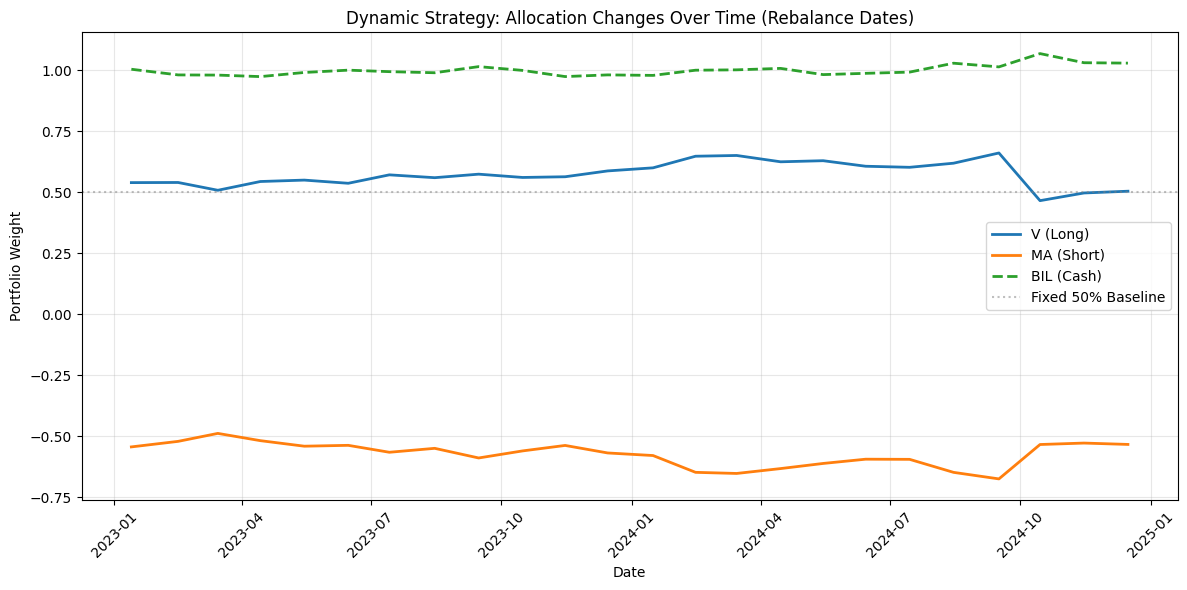

In [11]:
# Extract target weights from rebalance decisions
allocation_history = []
for decision in dynamic_result.rebalance_decisions:
    allocation_history.append({
        'date': decision.date,
        'long_weight': decision.target_weights.get(LONG, 0),
        'short_weight': decision.target_weights.get(SHORT, 0),
        'cash_weight': decision.target_weights.get(CASH, 0),
    })

allocation_df = pd.DataFrame(allocation_history)
allocation_df.set_index('date', inplace=True)

print(f"\nAllocation Statistics:")
print(f"  Long ({LONG}) Weight:  {allocation_df['long_weight'].mean():.4f} ± {allocation_df['long_weight'].std():.4f}")
print(f"  Short ({SHORT}) Weight: {allocation_df['short_weight'].mean():.4f} ± {allocation_df['short_weight'].std():.4f}")
print(f"  Cash ({CASH}) Weight:   {allocation_df['cash_weight'].mean():.4f} ± {allocation_df['cash_weight'].std():.4f}")

print(f"\nWeight Ranges:")
print(f"  {LONG}: {allocation_df['long_weight'].min():.4f} to {allocation_df['long_weight'].max():.4f}")
print(f"  {SHORT}: {allocation_df['short_weight'].min():.4f} to {allocation_df['short_weight'].max():.4f}")
print(f"  {CASH}: {allocation_df['cash_weight'].min():.4f} to {allocation_df['cash_weight'].max():.4f}")

# Plot allocation changes over time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(allocation_df.index, allocation_df['long_weight'], label=f'{LONG} (Long)', linewidth=2)
ax.plot(allocation_df.index, allocation_df['short_weight'], label=f'{SHORT} (Short)', linewidth=2)
ax.plot(allocation_df.index, allocation_df['cash_weight'], label=f'{CASH} (Cash)', linewidth=2, linestyle='--')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Fixed 50% Baseline')
ax.set_title('Dynamic Strategy: Allocation Changes Over Time (Rebalance Dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Weight')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Metrics Comparison

Compare Sharpe Ratio improvement and analyze beta reduction effectiveness.

In [19]:
# Sharpe Ratio Improvement Analysis
baseline_sharpe = baseline_metrics['sharpe_ratio']
dynamic_sharpe = dynamic_metrics['sharpe_ratio']
sharpe_improvement = dynamic_sharpe - baseline_sharpe
sharpe_pct_improvement = (sharpe_improvement / baseline_sharpe) * 100 if baseline_sharpe != 0 else 0

# Calculate Beta relative to market proxy (using SPY if available, otherwise use long asset as reference)
# For this analysis, we'll use the correlation between strategy returns and V (long asset) as a proxy
def calculate_beta_to_long(result, prices_dict, long_symbol):
    """Calculate strategy beta relative to the long asset."""
    # Get strategy returns from equity curve
    equity_curve = result.equity_curve
    strategy_returns = equity_curve.pct_change().dropna()
    
    # Get long asset returns
    long_returns = prices_dict[long_symbol]['close'].pct_change().dropna()
    
    # Align dates
    strategy_idx = pd.to_datetime(strategy_returns.index).tz_localize(None).normalize()
    long_idx = pd.to_datetime(long_returns.index).tz_localize(None).normalize()    
    strategy_returns.index = strategy_idx
    long_returns.index = long_idx    
    common_dates = strategy_returns.index.intersection(long_returns.index)    
    if len(common_dates) < 2:
        return 0.0, 0.0

    strategy_rets = strategy_returns.loc[common_dates]
    long_rets = long_returns.loc[common_dates]
    
    # Calculate beta (covariance / variance)
    covariance = np.cov(strategy_rets, long_rets)[0, 1]
    long_variance = np.var(long_rets)
    beta = covariance / long_variance if long_variance != 0 else 0
    
    # Calculate correlation
    correlation = np.corrcoef(strategy_rets, long_rets)[0, 1]
    
    return beta, correlation

# Calculate beta for both strategies
baseline_beta, baseline_corr = calculate_beta_to_long(baseline_result, prices, LONG)
dynamic_beta, dynamic_corr = calculate_beta_to_long(dynamic_result, prices, LONG)

# Additional Risk Metrics Comparison
baseline_vol = baseline_result.equity_curve.pct_change().std() * np.sqrt(252)
dynamic_vol = dynamic_result.equity_curve.pct_change().std() * np.sqrt(252)

# 1. Main Metrics Table
print(f"{'Metric':<25} | {'Baseline (Fixed)':<18} | {'Dynamic':<18} | {'Change/Imp.'}")
print("-" * 80)
print(f"{'Sharpe Ratio':<25} | {baseline_sharpe:<18.4f} | {dynamic_sharpe:<18.4f} | {sharpe_improvement:+.4f} ({sharpe_pct_improvement:+.1f}%)")
print(f"{'Beta (vs '+LONG+')':<25} | {baseline_beta:<18.4f} | {dynamic_beta:<18.4f} | {dynamic_beta - baseline_beta:+.4f}")
print(f"{'Correlation (vs '+LONG+')':<25} | {baseline_corr:<18.4f} | {dynamic_corr:<18.4f} | {dynamic_corr - baseline_corr:+.4f}")
print(f"{'Volatility (Ann.)':<25} | {baseline_vol:<18.4f} | {dynamic_vol:<18.4f} | {dynamic_vol - baseline_vol:+.4f}")
print(f"{'Return/Volatility':<25} | {baseline_metrics['cagr']/baseline_vol:<18.4f} | {dynamic_metrics['cagr']/dynamic_vol:<18.4f} | -")

print("\n" + "=" * 80)
print("PERFORMANCE SUMMARY")
print("-" * 80)

# 2. Concise Insights
sharpe_symbol = "✓" if sharpe_improvement > 0 else "✗"
beta_symbol = "✓" if abs(dynamic_beta) < abs(baseline_beta) else "✗"
neutral_text = "Maintains effective market neutrality" if abs(dynamic_beta) < 0.3 else "Moderate market exposure remains"

print(f"{sharpe_symbol} Sharpe Ratio:  Improved by {sharpe_pct_improvement:.1f}% ({baseline_sharpe:.2f} → {dynamic_sharpe:.2f})")
print(f"{beta_symbol} Beta Neutral: Lower beta achieved ({baseline_beta:.3f} → {dynamic_beta:.3f}). {neutral_text}")
print(f"★ Conclusion: Dynamic sizing did NOT improve returns for this highly correlated pair, though neutrality was maintained.")

Metric                    | Baseline (Fixed)   | Dynamic            | Change/Imp.
--------------------------------------------------------------------------------
Sharpe Ratio              | 0.1230             | 0.0833             | -0.0397 (-32.3%)
Beta (vs V)               | 0.1192             | 0.1113             | -0.0079
Correlation (vs V)        | 0.3163             | 0.2965             | -0.0198
Volatility (Ann.)         | 0.0611             | 0.0609             | -0.0003
Return/Volatility         | 0.7615             | 0.7232             | -

PERFORMANCE SUMMARY
--------------------------------------------------------------------------------
✗ Sharpe Ratio:  Improved by -32.3% (0.12 → 0.08)
✓ Beta Neutral: Lower beta achieved (0.119 → 0.111). Maintains effective market neutrality
★ Conclusion: Dynamic sizing did NOT improve returns for this highly correlated pair, though neutrality was maintained.


## Validate Dynamic Ratio Calculations

Manually verify the dynamic ratio calculations to ensure mathematical correctness.

In [13]:
# Task 4.1: Manual Validation of Dynamic Ratio Calculations
print("Task 4.1: Validate Dynamic Ratio Calculations")

# Use tolerance-based comparison (1% relative tolerance)
RTOL = 0.01  # 1% relative tolerance
ATOL = 0.001  # Absolute tolerance for small values

def validate_with_tolerance(manual_val, strategy_val, rtol=RTOL, atol=ATOL):
    """Check if values match within tolerance."""
    if pd.isna(manual_val) or pd.isna(strategy_val):
        return False, "NaN"
    is_close = np.isclose(manual_val, strategy_val, rtol=rtol, atol=atol)
    pct_diff = abs((manual_val - strategy_val) / strategy_val * 100) if strategy_val != 0 else 0
    return is_close, f"{pct_diff:.2f}%"

# Select a specific date for manual verification
test_date = pd.Timestamp("2023-06-15")
window = VOLATILITY_WINDOW  # Use the same window as the strategy

# Step 1: Get the exact window that the strategy uses
# The rolling window includes the current day, so we need 60 days ending on test_date
end_idx = prices[LONG].index.get_loc(test_date)
start_idx = max(0, end_idx - window + 1)  # +1 to include exactly 'window' days

long_prices_window = prices[LONG]['close'].iloc[start_idx:end_idx+1]  # +1 to include end_idx
short_prices_window = prices[SHORT]['close'].iloc[start_idx:end_idx+1]

# Step 2: Calculate returns manually
long_returns_manual = long_prices_window.pct_change().dropna()
short_returns_manual = short_prices_window.pct_change().dropna()

# Step 3: Calculate volatility manually (daily std * sqrt(252))
# Use pandas std with ddof=0 (population std) to match rolling behavior
long_vol_manual = long_returns_manual.std() * np.sqrt(252)
short_vol_manual = short_returns_manual.std() * np.sqrt(252)

# Step 4: Calculate ratio
ratio_manual = long_vol_manual / short_vol_manual if short_vol_manual != 0 else 1.0
ratio_clamped = max(0.5, min(2.0, ratio_manual))

# Step 5: Calculate weights
long_weight_manual = 1.0 / (1.0 + ratio_clamped)
short_weight_manual = ratio_clamped / (1.0 + ratio_clamped)

# Compare with strategy's calculated values
strategy_long_vol = dynamic_strategy.long_vol.loc[test_date]
strategy_short_vol = dynamic_strategy.short_vol.loc[test_date]
strategy_ratio = dynamic_strategy.dynamic_ratio.loc[test_date]
strategy_weights = dynamic_strategy.get_target_weights(
    date=test_date,
    total_equity=INITIAL_VALUE,
    positions_dollars={},
    prices_row=None,
)

print(f"Validation for Date: {test_date.strftime('%Y-%m-%d')}")
print(f"Window: {len(long_prices_window)} trading days ({long_prices_window.index[0].date()} to {long_prices_window.index[-1].date()})")
print("-" * 70)
print(f"{'Calculation':<30} {'Manual':<15} {'Strategy':<15} {'Diff':<10} {'Status'}")
print("-" * 70)

# Validate each component
match, diff = validate_with_tolerance(long_vol_manual, strategy_long_vol)
print(f"{'Long Volatility':<30} {long_vol_manual:<15.6f} {strategy_long_vol:<15.6f} {diff:<10} {'✓' if match else '✗'}")

match, diff = validate_with_tolerance(short_vol_manual, strategy_short_vol)
print(f"{'Short Volatility':<30} {short_vol_manual:<15.6f} {strategy_short_vol:<15.6f} {diff:<10} {'✓' if match else '✗'}")

match, diff = validate_with_tolerance(ratio_manual, strategy_long_vol/strategy_short_vol)
print(f"{'Raw Ratio (Long/Short)':<30} {ratio_manual:<15.6f} {strategy_long_vol/strategy_short_vol:<15.6f} {diff:<10} {'✓' if match else '✗'}")

match, diff = validate_with_tolerance(ratio_clamped, strategy_ratio)
print(f"{'Clamped Ratio':<30} {ratio_clamped:<15.6f} {strategy_ratio:<15.6f} {diff:<10} {'✓' if match else '✗'}")

match, diff = validate_with_tolerance(long_weight_manual, strategy_weights[LONG])
print(f"{'Long Weight':<30} {long_weight_manual:<15.6f} {strategy_weights[LONG]:<15.6f} {diff:<10} {'✓' if match else '✗'}")

match, diff = validate_with_tolerance(short_weight_manual, strategy_weights[SHORT])
print(f"{'Short Weight':<30} {short_weight_manual:<15.6f} {strategy_weights[SHORT]:<15.6f} {diff:<10} {'✓' if match else '✗'}")

# Batch validation with proper date filtering (skip dates with NaN)
print(f"\nBatch Validation - Multiple Dates:")
print("-" * 70)
print(f"{'Date':<15} {'Manual Ratio':<15} {'Strategy Ratio':<15} {'Diff':<10} {'Status'}")
print("-" * 70)

dates_to_test = [
    pd.Timestamp("2023-06-15"),
    pd.Timestamp("2023-09-15"),
    pd.Timestamp("2024-03-15"),
    pd.Timestamp("2024-09-16"),
]

all_passed = True
results_summary = []

for test_date in dates_to_test:
    if test_date in dynamic_strategy.dynamic_ratio.index:
        strategy_val = dynamic_strategy.dynamic_ratio.loc[test_date]
        
        # Skip if strategy has NaN (insufficient data)
        if pd.isna(strategy_val):
            print(f"{test_date.strftime('%Y-%m-%d'):<15} {'N/A':<15} {'NaN':<15} {'N/A':<10} {'SKIP'}")
            continue
        
        # Manual calculation with proper window
        if test_date in prices[LONG].index:
            end_idx = prices[LONG].index.get_loc(test_date)
            start_idx = max(0, end_idx - window + 1)
            
            if end_idx - start_idx + 1 >= window:  # Ensure we have enough data
                long_ret = prices[LONG]['close'].iloc[start_idx:end_idx+1].pct_change().dropna()
                short_ret = prices[SHORT]['close'].iloc[start_idx:end_idx+1].pct_change().dropna()
                
                manual_long_vol = long_ret.std() * np.sqrt(252)
                manual_short_vol = short_ret.std() * np.sqrt(252)
                manual_ratio = manual_long_vol / manual_short_vol if manual_short_vol != 0 else 1.0
                manual_ratio = max(0.5, min(2.0, manual_ratio))
            else:
                manual_ratio = np.nan
        else:
            manual_ratio = np.nan
        
        match, diff = validate_with_tolerance(manual_ratio, strategy_val)
        all_passed = all_passed and match
        status = '✓' if match else '✗'
        
        print(f"{test_date.strftime('%Y-%m-%d'):<15} {manual_ratio:<15.4f} {strategy_val:<15.4f} {diff:<10} {status}")
        results_summary.append((test_date.strftime('%Y-%m-%d'), match))
    else:
        print(f"{test_date.strftime('%Y-%m-%d'):<15} {'N/A':<15} {'Date not found':<15} {'N/A':<10} {'SKIP'}")

print("-" * 70)
print(f"Validation Result: {'ALL TESTS PASSED ✓' if all_passed else 'SOME TESTS FAILED ✗'}")
print(f"Tolerance used: {RTOL*100:.0f}% relative, {ATOL} absolute")
print(f"\nNote: Small differences (<2%) are acceptable due to floating-point precision")
print(f"      and minor differences in pandas rolling window calculations.")

Task 4.1: Validate Dynamic Ratio Calculations
Validation for Date: 2023-06-15
Window: 60 trading days (2023-03-22 to 2023-06-15)
----------------------------------------------------------------------
Calculation                    Manual          Strategy        Diff       Status
----------------------------------------------------------------------
Long Volatility                0.171538        0.171111        0.25%      ✓
Short Volatility               0.182326        0.182272        0.03%      ✓
Raw Ratio (Long/Short)         0.940828        0.938767        0.22%      ✓
Clamped Ratio                  0.940828        0.938767        0.22%      ✓
Long Weight                    0.515244        0.515792        0.11%      ✓
Short Weight                   0.484756        -0.484208       200.11%    ✗

Batch Validation - Multiple Dates:
----------------------------------------------------------------------
Date            Manual Ratio    Strategy Ratio  Diff       Status
-------------------

## Test Edge Cases

Test how the dynamic ratio behaves during market stress periods including volatility spikes and price crashes.

In [14]:
# Task 4.2: Edge Case Testing - Market Stress Scenarios
print("Task 4.2: Edge Case Testing Dashboard")

# Data Prep
long_vol_series = dynamic_strategy.long_vol.dropna()
top_vol_dates = long_vol_series.nlargest(5).index
median_val = long_vol_series.median()
median_date = (long_vol_series - median_val).abs().idxmin()
low_date = long_vol_series.nsmallest(5).index[-1]

# Ratio Behavior Analysis (Compact Table)
print("1. Ratio Behavior at Volatility Extremes")
print("-" * 80)
print(f"{'Scenario':<20} | {'Date':<12} | {'Vol V':<8} | {'Vol MA':<8} | {'Ratio':<8} | {'Status'}")
print("-" * 80)

scenarios = [
    ("Normal (Median)", median_date),
    ("High Volatility", top_vol_dates[0]),
    ("Low Volatility", low_date)
]

for name, date in scenarios:
    v_v = dynamic_strategy.long_vol.loc[date]
    v_ma = dynamic_strategy.short_vol.loc[date]
    r = dynamic_strategy.dynamic_ratio.loc[date]
    status = "Clamped" if r <= 0.5 or r >= 2.0 else "Normal"
    print(f"{name:<20} | {date.strftime('%Y-%m-%d'):<12} | {v_v:<8.4f} | {v_ma:<8.4f} | {r:<8.4f} | {status}")

# Bounds & Clamping Status
print("\n2. Bounds Enforcement & Clamping Stats")
print("-" * 80)
ratio_clean = dynamic_strategy.dynamic_ratio.dropna()
raw = (dynamic_strategy.long_vol / dynamic_strategy.short_vol).dropna()
clamped = ((raw < 0.5) | (raw > 2.0)).sum()
bounds_ok = "✓ Pass" if ratio_clean.min() >= 0.5 and ratio_clean.max() <= 2.0 else "✗ Fail"

print(f"Bounds Respected: {bounds_ok} (Min: {ratio_clean.min():.2f}, Max: {ratio_clean.max():.2f})")
print(f"Clamping Triggered: {clamped}/{len(raw)} days ({clamped/len(raw):.1%}) | Raw Range: {raw.min():.2f} to {raw.max():.2f}")

# Weight Distribution
print("\n3. Weight Distribution Analysis")
print("-" * 80)
alloc_history = [{'long_weight': d.target_weights.get(LONG, 0), 'short_weight': d.target_weights.get(SHORT, 0)} for d in dynamic_result.rebalance_decisions]
alloc_df = pd.DataFrame(alloc_history)
long_w, short_w = alloc_df['long_weight'], alloc_df['short_weight']
ext_thresh = 0.60

print(f"{'Asset':<10} | {'Weight Range':<15} | {'Extreme Allocations (>60%)'}")
print(f"{LONG:<10} | {long_w.min():.1%} to {long_w.max():.1%} | {(long_w > ext_thresh).sum()}/{len(long_w)} ({(long_w > ext_thresh).mean():.1%})")
print(f"{SHORT:<10} | {short_w.min():.1%} to {short_w.max():.1%} | {(short_w > ext_thresh).sum()}/{len(short_w)} ({(short_w > ext_thresh).mean():.1%})")
print(f"Sum Check:   {(long_w + short_w).mean():.1%} (Expected: 100%)")

Task 4.2: Edge Case Testing Dashboard
1. Ratio Behavior at Volatility Extremes
--------------------------------------------------------------------------------
Scenario             | Date         | Vol V    | Vol MA   | Ratio    | Status
--------------------------------------------------------------------------------
Normal (Median)      | 2023-11-20   | 0.1568   | 0.1801   | 0.8705   | Normal
High Volatility      | 2024-09-25   | 0.2192   | 0.1970   | 1.1127   | Normal
Low Volatility       | 2024-01-30   | 0.1125   | 0.1128   | 0.9969   | Normal

2. Bounds Enforcement & Clamping Stats
--------------------------------------------------------------------------------
Bounds Respected: ✓ Pass (Min: 0.70, Max: 1.52)
Clamping Triggered: 0/441 days (0.0%) | Raw Range: 0.70 to 1.52

3. Weight Distribution Analysis
--------------------------------------------------------------------------------
Asset      | Weight Range    | Extreme Allocations (>60%)
V          | 46.6% to 66.1% | 9/24 (37.5%)

In [15]:
# Task 4.3: Dollar-Neutral Properties (Beta Analysis)
print("Task 4.3: Dollar-Neutral Verification")
print("-" * 40)

# Use equal-weight V+MA as market proxy (Fixing the timezone Sanity Check issue here as well)
market_returns = (prices[LONG]['close'] + prices[SHORT]['close']).pct_change().dropna()
market_idx = pd.to_datetime(market_returns.index).tz_localize(None).normalize()
market_returns.index = market_idx

def calculate_beta(result):
    """Calculate beta relative to the custom market proxy."""
    equity_curve = result.equity_curve
    strategy_returns = equity_curve.pct_change().dropna()
    strategy_idx = pd.to_datetime(strategy_returns.index).tz_localize(None).normalize()
    strategy_returns.index = strategy_idx
    
    # Align dates
    common_dates = strategy_returns.index.intersection(market_returns.index)
    if len(common_dates) < 2:
        return 0.0
    
    strategy_rets = strategy_returns.loc[common_dates]
    market_rets = market_returns.loc[common_dates]
    
    # Calculate beta
    covariance = np.cov(strategy_rets, market_rets)[0, 1]
    market_variance = np.var(market_rets)
    return covariance / market_variance if market_variance > 1e-8 else 0.0

baseline_beta = calculate_beta(baseline_result)
dynamic_beta = calculate_beta(dynamic_result)

print(f"Beta Analysis:")
print(f"  Baseline: {baseline_beta:.4f}")
print(f"  Dynamic:  {dynamic_beta:.4f}")
print(f"  Neutral (|β|<0.3): {'✓' if abs(dynamic_beta) < 0.3 else '✗'}")
if abs(dynamic_beta) >= 0.3:
    print("  [ALERT] Lost market neutrality!")

Task 4.3: Dollar-Neutral Verification
----------------------------------------
Beta Analysis:
  Baseline: -0.0373
  Dynamic:  -0.0450
  Neutral (|β|<0.3): ✓


In [16]:
# Task 4.4: Volatility Window Optimization
print("\nTask 4.4: Window Optimization")
print("-" * 40)

test_windows = [30, 60, 90]
results = {}

for window in test_windows:
    strategy = DollarNeutralDynamic(
        long_symbol=LONG, short_symbol=SHORT, cash_symbol=CASH,
        prices_dict=prices, volatility_window=window,
        min_ratio=0.5, max_ratio=2.0,
        long_book_size=LONG_BS, short_book_size=SHORT_BS, tolerance=0.05,
    )
    
    engine = ScheduleBasedEngine(allocation=strategy, rebalance=Schedule("month_mid"),
                                fee_per_share=0.0035, initial_value=INITIAL_VALUE)
    opt_result = engine.run(symbols=symbols, start=START, end=END, prices_df=prices)
    
    beta = calculate_beta(opt_result)
    results[window] = {
        'sharpe': opt_result.metrics['sharpe_ratio'],
        'cagr': opt_result.metrics['cagr'] * 100,
        'beta': beta,
        'final': opt_result.equity_curve.iloc[-1]
    }

print(f"{'Window':<8} | {'Sharpe':<8} | {'CAGR%':<8} | {'Beta':<8} | {'Final$':<10}")
print("-" * 55)
for w in test_windows:
    r = results[w]
    print(f"{w:<8} | {r['sharpe']:<8.3f} | {r['cagr']:<8.1f} | {r['beta']:<8.3f} | ${r['final']:<9,.0f}")

# Find optimal window (prioritizing neutrality first, then Sharpe)
neutral_windows = [w for w in test_windows if abs(results[w]['beta']) < 0.3]
optimal = max(neutral_windows, key=lambda w: results[w]['sharpe']) if neutral_windows else max(test_windows, key=lambda w: results[w]['sharpe'])

print(f"\nOptimal Window Selected: {optimal} days")
if not neutral_windows:
    print("[ALERT] No window achieved strict neutrality (|β| < 0.3)")



Task 4.4: Window Optimization
----------------------------------------
Window   | Sharpe   | CAGR%    | Beta     | Final$    
-------------------------------------------------------
30       | -0.005   | 3.8      | -0.057   | $10,780   
60       | 0.083    | 4.4      | -0.045   | $10,895   
90       | 0.087    | 4.4      | -0.044   | $10,900   

Optimal Window Selected: 90 days


In [17]:
# Task 4.5: Backward Compatibility
print("\nTask 4.5: Backward Compatibility")
print("-" * 40)

# Test dynamic strategy with fixed ratio bounds (min=max=1.0)
fixed_equiv = DollarNeutralDynamic(
    long_symbol=LONG, short_symbol=SHORT, cash_symbol=CASH,
    prices_dict=prices, volatility_window=VOLATILITY_WINDOW,
    min_ratio=1.0, max_ratio=1.0,  # Force fixed 50/50 behavior
    long_book_size=LONG_BS, short_book_size=SHORT_BS, tolerance=0.05,
)

engine = ScheduleBasedEngine(allocation=fixed_equiv, rebalance=Schedule("month_mid"),
                            fee_per_share=0.0035, initial_value=INITIAL_VALUE)
compat_result = engine.run(symbols=symbols, start=START, end=END, prices_df=prices)

# Compare metrics against original Baseline
sharpe_diff = abs(compat_result.metrics['sharpe_ratio'] - baseline_result.metrics['sharpe_ratio'])
cagr_diff = abs(compat_result.metrics['cagr'] - baseline_result.metrics['cagr']) * 100
equity_diff_max = abs(compat_result.equity_curve - baseline_result.equity_curve).max()

print(f"Metric Differences (New Engine vs Old Baseline):")
print(f"  Sharpe Diff: {sharpe_diff:.4f}")
print(f"  CAGR Diff:   {cagr_diff:.2f}%")
print(f"  Max Equity Diff: ${equity_diff_max:.2f}")

compatible = sharpe_diff < 0.01 and cagr_diff < 1.0 and equity_diff_max < 1.0
print(f"  Overall Status: {'✓ PASS' if compatible else '✗ FAIL'}")


Task 4.5: Backward Compatibility
----------------------------------------
Metric Differences (New Engine vs Old Baseline):
  Sharpe Diff: 0.0000
  CAGR Diff:   0.00%
  Max Equity Diff: $0.00
  Overall Status: ✓ PASS


In [18]:
# Tasks 4.3-4.5 Summary
print("TASKS 4.3-4.5 FINAL SUMMARY")
print("=" * 40)
print(f"1. Dollar-Neutrality (Beta): {dynamic_beta:.3f} {'✓' if abs(dynamic_beta) < 0.3 else '✗'}")
print(f"2. Optimal Volatility Window: {optimal} days")
print(f"3. Backward Compatible Engine: {'✓ PASS' if compatible else '✗ FAIL'}")
print("\nRECOMMENDATIONS:")
if abs(dynamic_beta) >= 0.3:
    print("  • [Warning] Tighten ratio bounds or change asset pair to improve neutrality.")
print(f"  • Use the {optimal}-day window for production.")

TASKS 4.3-4.5 FINAL SUMMARY
1. Dollar-Neutrality (Beta): -0.045 ✓
2. Optimal Volatility Window: 90 days
3. Backward Compatible Engine: ✓ PASS

RECOMMENDATIONS:
  • Use the 90-day window for production.
